Top channels: ['Fp2', 'Oz', 'F4', 'Fpz', 'M1', 'FC2']


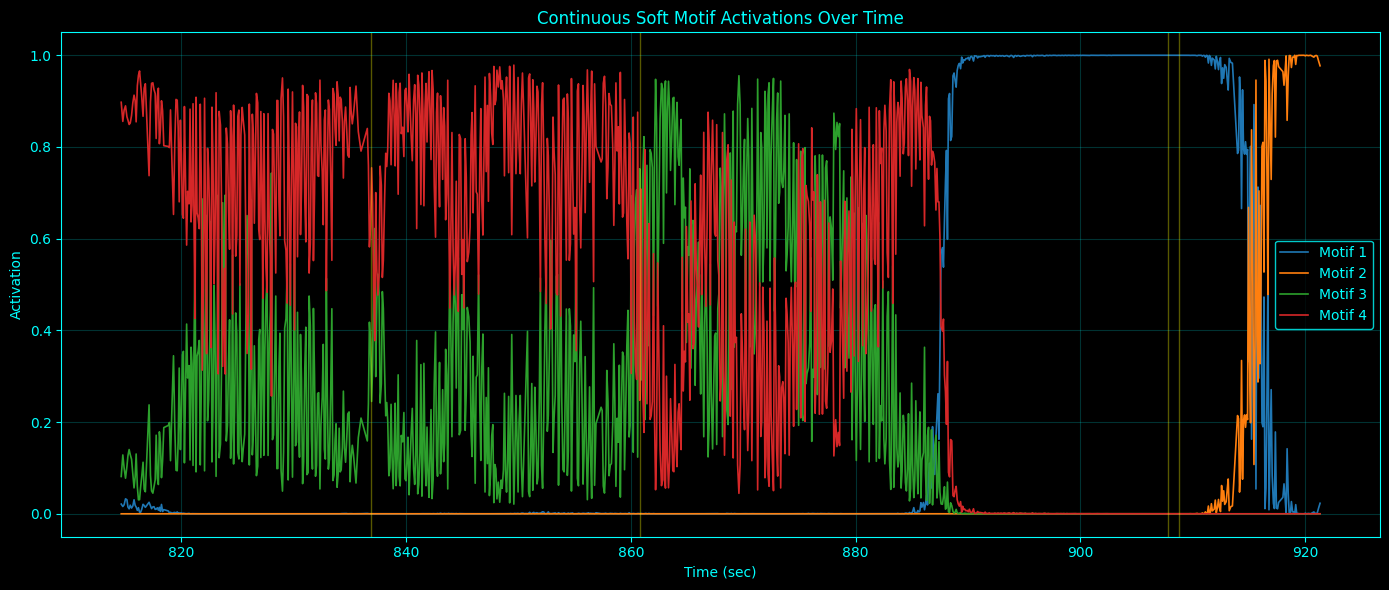

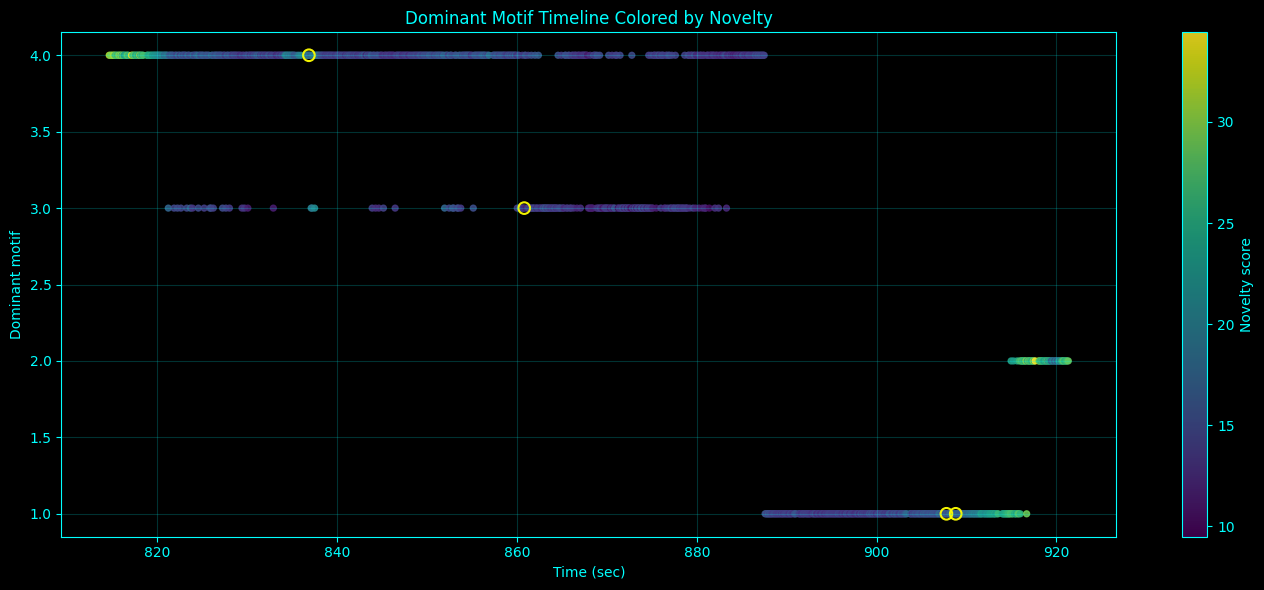

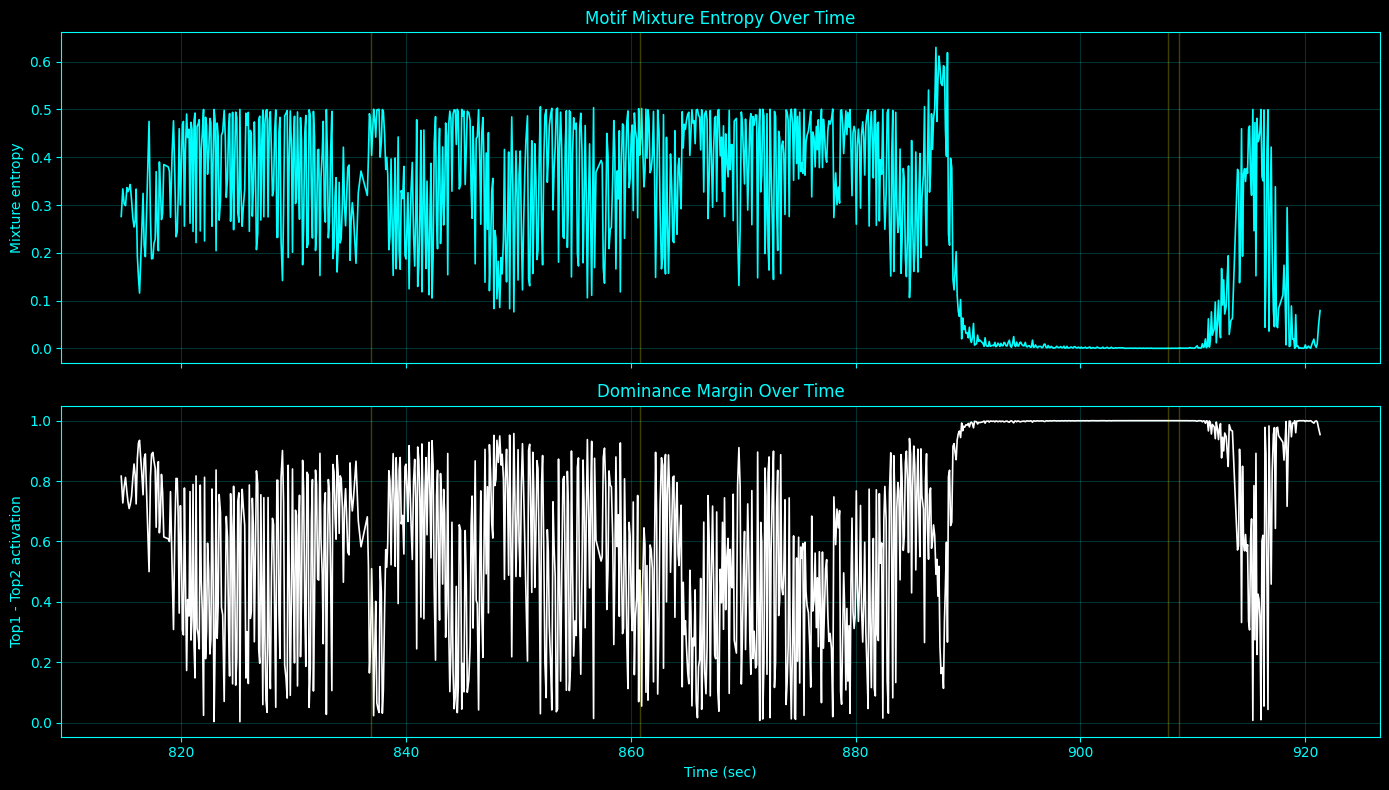

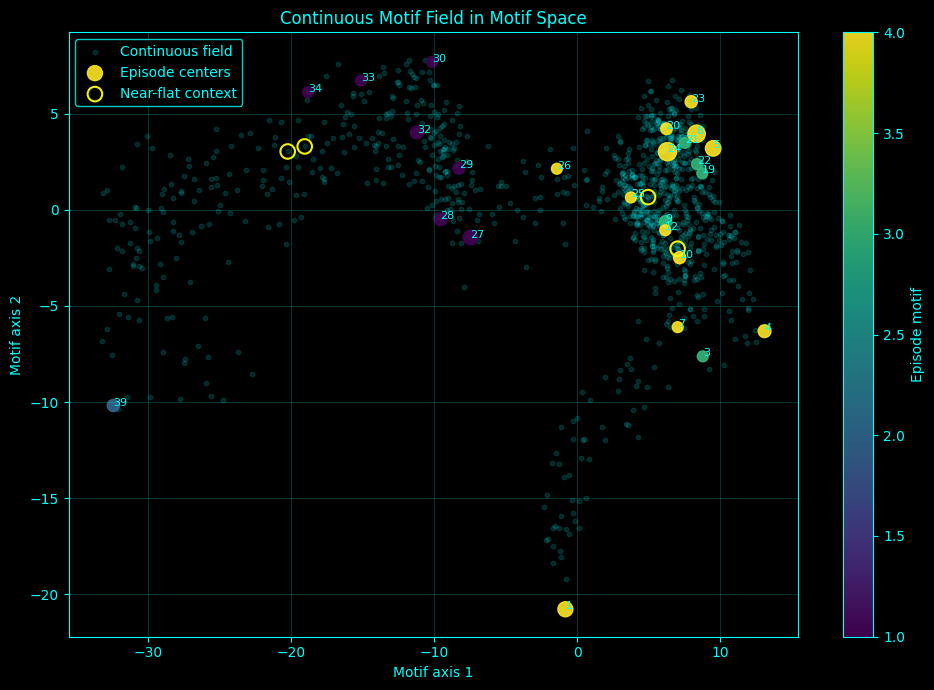

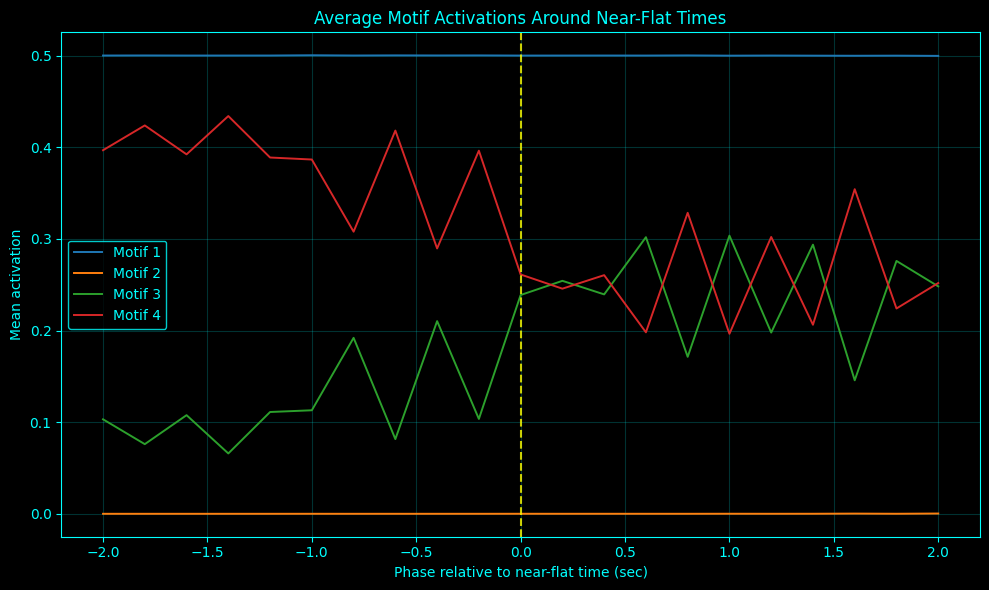


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/continuous_motif_field.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/motif_prototypes_from_window_descriptors.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/episode_center_window_descriptors.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/near_flat_soft_motif_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/near_flat_motif_precursor_profiles.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/continuous_motif_field_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/plots

Saved plots:
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/plots/continuous_motif_activations.png
/home/a/projects/Complete-Neural-Signal-Analysis/res

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

motif_dir = os.path.join(base_dir, "results", "episode_motif_manifold_v1")
geom_dir = os.path.join(base_dir, "results", "local_banach_curvature_bootstrap_v1")
temporal_dir = os.path.join(base_dir, "results", "stable_curvature_temporal_episodes_v1")

episode_feature_csv = os.path.join(motif_dir, "episode_motif_features.csv")
all_local_csv = os.path.join(geom_dir, "local_chart_curvature_all_states.csv")
near_flat_context_csv = os.path.join(base_dir, "results", "stable_episode_corridor_atlas_v1", "near_flat_episode_context.csv")
channel_contrast_csv = os.path.join(temporal_dir, "stable_vs_nonstable_channel_envelope_contrast.csv")

out_dir = os.path.join(base_dir, "results", "continuous_motif_field_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# sliding descriptor controls
field_stride = 10              # every 10th kept state center
phase_window_sec = 2.0
phase_bin_sec = 0.20
top_k_channels = 6
env_smooth_sec = 0.150

# soft assignment controls
softmax_temperature = 1.0

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    w = max(int(w), 1)
    if w <= 1:
        return x.copy()
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(x, kernel, mode="same")

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

def interp_profile(bin_centers, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if len(x) == 0:
        return np.full(len(bin_centers), np.nan)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if len(np.unique(x)) == 1:
        return np.full(len(bin_centers), y[0])

    return np.interp(bin_centers, x, y, left=y[0], right=y[-1])

def zscore_with_ref(X, mu, sd):
    return (X - mu) / (sd + eps)

def softmax_negdist(d, temperature=1.0):
    d = np.asarray(d, dtype=float)
    z = -d / max(temperature, eps)
    z = z - np.max(z)
    p = np.exp(z)
    return p / (np.sum(p) + eps)

def entropy01(p):
    p = np.asarray(p, dtype=float)
    p = p / (np.sum(p) + eps)
    h = -np.sum(p * np.log(p + eps))
    return float(h / (np.log(len(p) + eps) + eps))

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
episode_feature_df = pd.read_csv(episode_feature_csv).sort_values("center_time_sec").reset_index(drop=True)
all_local_df = pd.read_csv(all_local_csv).sort_values("time_sec").reset_index(drop=True)

if os.path.exists(near_flat_context_csv):
    near_flat_context_df = pd.read_csv(near_flat_context_csv)
else:
    near_flat_context_df = pd.DataFrame()

if os.path.exists(channel_contrast_csv):
    channel_contrast_df = pd.read_csv(channel_contrast_csv).sort_values(
        "cohen_d_stable_vs_nonstable", ascending=False
    ).reset_index(drop=True)
    top_channels = channel_contrast_df["channel"].head(top_k_channels).tolist()
else:
    top_channels = ["Fp2", "Oz", "F4", "Fpz", "M1", "FC2"]

top_channel_idx = [eeg_channel_names.index(ch) for ch in top_channels]
print("Top channels:", top_channels)

all_local_df["abs_laplacian_norm_proxy"] = np.abs(all_local_df["laplacian_norm_proxy"].values)

# -------------------------------------------------------
# LOAD EEG FOR CHANNEL DESCRIPTORS
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

analytic = hilbert(EEG_segment, axis=0)
envelope = np.abs(analytic)
env_z = (envelope - np.mean(envelope, axis=0, keepdims=True)) / (np.std(envelope, axis=0, keepdims=True) + eps)

smooth_w = int(env_smooth_sec * sampling_rate)
env_z_smooth = np.column_stack([
    moving_average(env_z[:, ch], smooth_w) for ch in range(env_z.shape[1])
])

sample_time = start_time + np.arange(len(EEG_segment)) * dt

# -------------------------------------------------------
# BUILD COMPARABLE WINDOW DESCRIPTORS
# -------------------------------------------------------
phase_bins = np.arange(-phase_window_sec, phase_window_sec + phase_bin_sec, phase_bin_sec)

state_metric_cols = [
    "frobenius_norm_proxy",
    "abs_laplacian_norm_proxy",
    "transition_distortion_B",
    "reduced_logvol_per_rank_B",
    "mean_banach_neighbor_radius",
    "fit_r2",
]

def build_window_descriptor(center_t):
    # state-level profiles
    sub = all_local_df[
        (all_local_df["time_sec"] >= center_t - phase_window_sec) &
        (all_local_df["time_sec"] <= center_t + phase_window_sec)
    ].copy()

    if len(sub) < 5:
        return None

    phase_state = sub["time_sec"].values - center_t

    desc_parts = []
    summary_parts = []

    for col in state_metric_cols:
        prof = interp_profile(phase_bins, phase_state, sub[col].values)
        desc_parts.append(prof)

        pre = safe_mean(prof[(phase_bins >= -1.5) & (phase_bins <= -0.5)])
        ctr = safe_mean(prof[(phase_bins >= -0.25) & (phase_bins <= 0.25)])
        post = safe_mean(prof[(phase_bins >= 0.5) & (phase_bins <= 1.5)])

        summary_parts.extend([
            pre,
            ctr,
            post,
            ctr - pre,
            post - ctr
        ])

    # channel profiles
    sample_mask = (
        (sample_time >= center_t - phase_window_sec) &
        (sample_time <= center_t + phase_window_sec)
    )

    if not np.any(sample_mask):
        return None

    phase_sample = sample_time[sample_mask] - center_t
    for ch_idx in top_channel_idx:
        prof = interp_profile(phase_bins, phase_sample, env_z_smooth[sample_mask, ch_idx])
        desc_parts.append(prof)

        pre = safe_mean(prof[(phase_bins >= -1.5) & (phase_bins <= -0.5)])
        ctr = safe_mean(prof[(phase_bins >= -0.25) & (phase_bins <= 0.25)])
        post = safe_mean(prof[(phase_bins >= 0.5) & (phase_bins <= 1.5)])

        summary_parts.extend([
            pre,
            ctr,
            post,
            ctr - pre,
            post - ctr
        ])

    descriptor = np.concatenate(desc_parts + [np.asarray(summary_parts, dtype=float)])
    return descriptor

# -------------------------------------------------------
# EPISODE-CENTER DESCRIPTORS FOR MOTIF PROTOTYPES
# -------------------------------------------------------
ep_desc_rows = []

for _, row in episode_feature_df.iterrows():
    center_t = float(row["center_time_sec"])
    d = build_window_descriptor(center_t)
    if d is None:
        continue

    out = {
        "episode_id": int(row["episode_id"]),
        "center_time_sec": center_t,
        "motif_id": int(row["motif_id"]),
        "has_near_flat": int(row["has_near_flat"]),
        "n_stable_states": int(row["n_stable_states"]),
    }
    for i, v in enumerate(d):
        out[f"d_{i:03d}"] = float(v)
    ep_desc_rows.append(out)

ep_desc_df = pd.DataFrame(ep_desc_rows).sort_values("center_time_sec").reset_index(drop=True)

desc_cols = [c for c in ep_desc_df.columns if c.startswith("d_")]
X_ep = ep_desc_df[desc_cols].values

mu = np.nanmean(X_ep, axis=0, keepdims=True)
sd = np.nanstd(X_ep, axis=0, keepdims=True)
X_ep_z = zscore_with_ref(X_ep, mu, sd)

motifs = sorted(ep_desc_df["motif_id"].unique())
prototype_rows = []

for motif_id in motifs:
    sub = X_ep_z[ep_desc_df["motif_id"].values == motif_id]
    centroid = np.nanmean(sub, axis=0)
    row = {"motif_id": int(motif_id)}
    for i, v in enumerate(centroid):
        row[f"c_{i:03d}"] = float(v)
    prototype_rows.append(row)

prototype_df = pd.DataFrame(prototype_rows)
C = prototype_df[[c for c in prototype_df.columns if c.startswith("c_")]].values

# -------------------------------------------------------
# CONTINUOUS MOTIF FIELD
# -------------------------------------------------------
center_times = all_local_df["time_sec"].values[::field_stride]
field_rows = []

for center_t in center_times:
    d = build_window_descriptor(center_t)
    if d is None:
        continue

    dz = zscore_with_ref(d[None, :], mu, sd)[0]
    dist_to_centroids = np.linalg.norm(C - dz[None, :], axis=1)
    probs = softmax_negdist(dist_to_centroids, temperature=softmax_temperature)

    dominant_idx = int(np.argmax(probs))
    dominant_motif = int(motifs[dominant_idx])

    sorted_probs = np.sort(probs)[::-1]
    margin = float(sorted_probs[0] - sorted_probs[1]) if len(sorted_probs) > 1 else 1.0

    row = {
        "center_time_sec": float(center_t),
        "dominant_motif": dominant_motif,
        "novelty_score": float(np.min(dist_to_centroids)),
        "mixture_entropy": entropy01(probs),
        "dominance_margin": margin,
    }

    for motif_id, p, distv in zip(motifs, probs, dist_to_centroids):
        row[f"motif_{motif_id}_activation"] = float(p)
        row[f"motif_{motif_id}_distance"] = float(distv)

    field_rows.append(row)

field_df = pd.DataFrame(field_rows).sort_values("center_time_sec").reset_index(drop=True)

# attach motif-space embedding of prototypes + field points
Y_ep, _, V2 = pca_2d(X_ep_z)
ep_desc_df["motif_x"] = Y_ep[:, 0]
ep_desc_df["motif_y"] = Y_ep[:, 1]

field_desc = []
for center_t in field_df["center_time_sec"].values:
    d = build_window_descriptor(center_t)
    dz = zscore_with_ref(d[None, :], mu, sd)[0]
    field_desc.append(dz)
field_desc = np.vstack(field_desc)

field_xy = (field_desc - np.mean(X_ep_z, axis=0, keepdims=True)) @ V2
field_df["motif_x"] = field_xy[:, 0]
field_df["motif_y"] = field_xy[:, 1]

# -------------------------------------------------------
# NEAR-FLAT CONTEXT IN SOFT MOTIF FIELD
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_context_df) > 0:
    for _, row in near_flat_context_df.iterrows():
        t = float(row["time_sec"])
        idx = int(np.argmin(np.abs(field_df["center_time_sec"].values - t)))
        fr = field_df.iloc[idx]

        out = {
            "time_sec": t,
            "nearest_field_time_sec": float(fr["center_time_sec"]),
            "dominant_motif": int(fr["dominant_motif"]),
            "novelty_score": float(fr["novelty_score"]),
            "mixture_entropy": float(fr["mixture_entropy"]),
            "dominance_margin": float(fr["dominance_margin"]),
            "motif_x": float(fr["motif_x"]),
            "motif_y": float(fr["motif_y"]),
        }
        for motif_id in motifs:
            out[f"motif_{motif_id}_activation"] = float(fr[f"motif_{motif_id}_activation"])
        near_flat_rows.append(out)

near_flat_field_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# AVERAGE PRECURSOR PROFILES AROUND NEAR-FLAT STATES
# -------------------------------------------------------
precursor_rows = []
precursor_window_sec = 2.0
precursor_bins = np.arange(-precursor_window_sec, precursor_window_sec + phase_bin_sec, phase_bin_sec)

if len(near_flat_field_df) > 0:
    for motif_id in motifs:
        aligned_profiles = []

        for t in near_flat_field_df["time_sec"].values:
            phase = field_df["center_time_sec"].values - t
            prof = interp_profile(
                precursor_bins,
                phase,
                field_df[f"motif_{motif_id}_activation"].values
            )
            aligned_profiles.append(prof)

        aligned_profiles = np.vstack(aligned_profiles)
        mean_prof = np.nanmean(aligned_profiles, axis=0)

        for p, v in zip(precursor_bins, mean_prof):
            precursor_rows.append({
                "motif_id": int(motif_id),
                "phase_sec": float(p),
                "mean_activation": float(v),
            })

precursor_df = pd.DataFrame(precursor_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
field_csv = os.path.join(out_dir, "continuous_motif_field.csv")
prototype_csv = os.path.join(out_dir, "motif_prototypes_from_window_descriptors.csv")
episode_desc_csv = os.path.join(out_dir, "episode_center_window_descriptors.csv")
near_flat_field_csv = os.path.join(out_dir, "near_flat_soft_motif_context.csv")
precursor_csv = os.path.join(out_dir, "near_flat_motif_precursor_profiles.csv")
summary_txt = os.path.join(out_dir, "continuous_motif_field_summary.txt")

field_df.to_csv(field_csv, index=False)
prototype_df.to_csv(prototype_csv, index=False)
ep_desc_df.to_csv(episode_desc_csv, index=False)
near_flat_field_df.to_csv(near_flat_field_csv, index=False)
precursor_df.to_csv(precursor_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Continuous Soft Motif Field Summary\n")
    f.write("=================================\n\n")
    f.write(f"Episode motif features: {episode_feature_csv}\n")
    f.write(f"State geometry: {all_local_csv}\n")
    f.write(f"Top channels: {top_channels}\n")
    f.write(f"Phase window sec: {phase_window_sec}\n")
    f.write(f"Phase bin sec: {phase_bin_sec}\n")
    f.write(f"Field stride: {field_stride}\n\n")

    f.write("Motif occupancy in continuous field:\n")
    f.write(field_df["dominant_motif"].value_counts().sort_index().to_string())
    f.write("\n\n")

    f.write("Top 20 novelty windows:\n")
    novelty_top = field_df.sort_values("novelty_score", ascending=False).head(20)
    f.write(novelty_top[[
        "center_time_sec", "dominant_motif", "novelty_score",
        "mixture_entropy", "dominance_margin"
    ]].to_string(index=False))
    f.write("\n\n")

    if len(near_flat_field_df) > 0:
        f.write("Near-flat soft motif context:\n")
        f.write(near_flat_field_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Continuous motif activations over time
fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

for motif_id in motifs:
    ax.plot(
        field_df["center_time_sec"].values,
        field_df[f"motif_{motif_id}_activation"].values,
        linewidth=1.2,
        label=f"Motif {motif_id}"
    )

if len(near_flat_field_df) > 0:
    for t in near_flat_field_df["time_sec"].values:
        ax.axvline(t, color="yellow", alpha=0.35, linewidth=1.0)

ax.set_title("Continuous Soft Motif Activations Over Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Activation")
ax.legend()

plot1_path = os.path.join(plots_dir, "continuous_motif_activations.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Dominant motif timeline with novelty overlay
fig, ax1 = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax1)

sc = ax1.scatter(
    field_df["center_time_sec"].values,
    field_df["dominant_motif"].values,
    c=field_df["novelty_score"].values,
    s=18,
    alpha=0.85
)
ax1.set_title("Dominant Motif Timeline Colored by Novelty")
ax1.set_xlabel("Time (sec)")
ax1.set_ylabel("Dominant motif")

if len(near_flat_field_df) > 0:
    ax1.scatter(
        near_flat_field_df["time_sec"].values,
        near_flat_field_df["dominant_motif"].values,
        s=70,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

cbar = plt.colorbar(sc, ax=ax1)
style_cbar(cbar, "Novelty score")

plot2_path = os.path.join(plots_dir, "dominant_motif_timeline_novelty.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Mixture entropy and dominance margin over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(
    field_df["center_time_sec"].values,
    field_df["mixture_entropy"].values,
    color=ACCENT,
    linewidth=1.2
)
ax1.set_title("Motif Mixture Entropy Over Time")
ax1.set_ylabel("Mixture entropy")

ax2.plot(
    field_df["center_time_sec"].values,
    field_df["dominance_margin"].values,
    color="white",
    linewidth=1.2
)
ax2.set_title("Dominance Margin Over Time")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Top1 - Top2 activation")

if len(near_flat_field_df) > 0:
    for t in near_flat_field_df["time_sec"].values:
        ax1.axvline(t, color="yellow", alpha=0.25, linewidth=1.0)
        ax2.axvline(t, color="yellow", alpha=0.25, linewidth=1.0)

plot3_path = os.path.join(plots_dir, "mixture_entropy_and_margin.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Motif-field manifold
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

ax.scatter(
    field_df["motif_x"].values,
    field_df["motif_y"].values,
    s=10,
    alpha=0.14,
    color=ACCENT,
    label="Continuous field"
)

sc = ax.scatter(
    ep_desc_df["motif_x"].values,
    ep_desc_df["motif_y"].values,
    c=ep_desc_df["motif_id"].values,
    s=45 + 8 * ep_desc_df["n_stable_states"].values,
    alpha=0.9,
    label="Episode centers"
)

for _, row in ep_desc_df.iterrows():
    ax.text(row["motif_x"], row["motif_y"], str(int(row["episode_id"])), fontsize=8)

if len(near_flat_field_df) > 0:
    ax.scatter(
        near_flat_field_df["motif_x"].values,
        near_flat_field_df["motif_y"].values,
        s=110,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95,
        label="Near-flat context"
    )

ax.set_title("Continuous Motif Field in Motif Space")
ax.set_xlabel("Motif axis 1")
ax.set_ylabel("Motif axis 2")
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Episode motif")

plot4_path = os.path.join(plots_dir, "continuous_motif_field_manifold.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Near-flat precursor activations
if len(precursor_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
    style_ax(ax)

    for motif_id in motifs:
        sub = precursor_df[precursor_df["motif_id"] == motif_id]
        ax.plot(
            sub["phase_sec"].values,
            sub["mean_activation"].values,
            linewidth=1.4,
            label=f"Motif {motif_id}"
        )

    ax.axvline(0.0, color="yellow", linestyle="--", alpha=0.8)
    ax.set_title("Average Motif Activations Around Near-Flat Times")
    ax.set_xlabel("Phase relative to near-flat time (sec)")
    ax.set_ylabel("Mean activation")
    ax.legend()

    plot5_path = os.path.join(plots_dir, "nearflat_motif_precursors.png")
    plt.tight_layout()
    plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plot5_path = None

print("\nSaved:")
print(field_csv)
print(prototype_csv)
print(episode_desc_csv)
print(near_flat_field_csv)
print(precursor_csv)
print(summary_txt)
print(plots_dir)

print("\nSaved plots:")
print(plot1_path)
print(plot2_path)
print(plot3_path)
print(plot4_path)
if plot5_path is not None:
    print(plot5_path)

print("\nQuick summary:")
print("Motif occupancy in continuous field:")
print(field_df["dominant_motif"].value_counts().sort_index().to_string())

print("\nTop 15 novelty windows:")
print(
    field_df.sort_values("novelty_score", ascending=False).head(15)[[
        "center_time_sec", "dominant_motif", "novelty_score",
        "mixture_entropy", "dominance_margin"
    ]].to_string(index=False)
)

if len(near_flat_field_df) > 0:
    print("\nNear-flat soft motif context:")
    print(near_flat_field_df.to_string(index=False))

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Principal component analysis</h3><p>PCA diagonalizes the sample covariance matrix and projects observations onto orthonormal directions of decreasing variance. If $C v_i=\lambda_i v_i$, the explained-variance ratio of component $i$ is $\lambda_i/\sum_j\lambda_j$.</p><p><b>Cell role.</b> This code applies that theory to the notebook's existing EEG-derived data and preserves the surrounding notebook's plotting/output conventions. Numerical shortcuts selected by a speed mode change sampling density, iteration counts, or visualization resolution; they do not change the defining formula above.</p></div>

$$C=\\frac{1}{N-1}X_c^{\\mathsf T}X_c,\\qquad Cv_i=\\lambda_i v_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


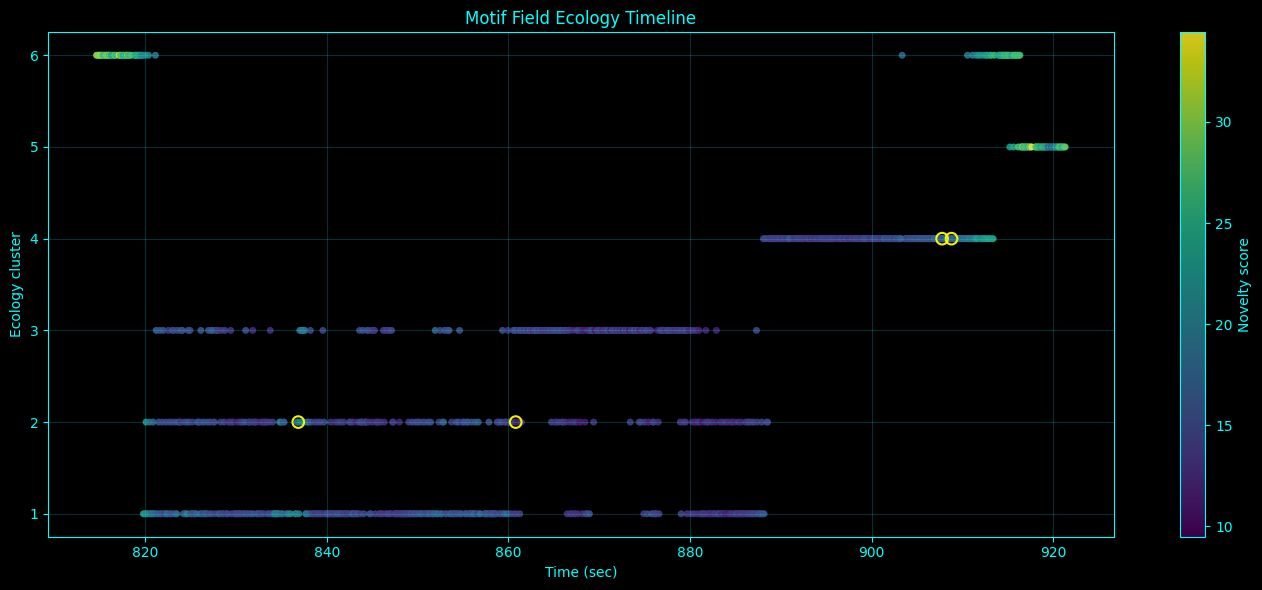

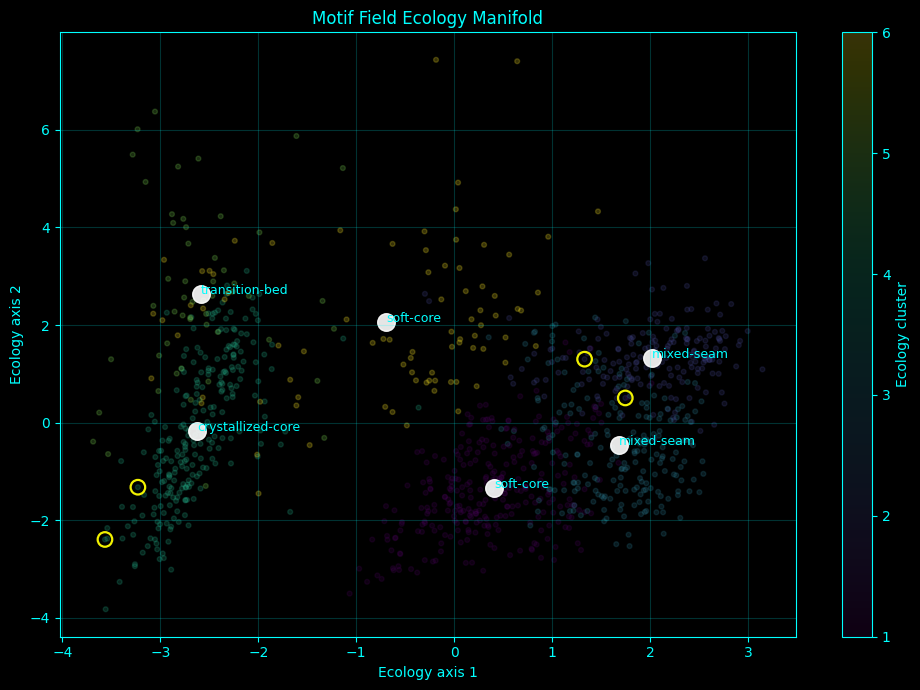

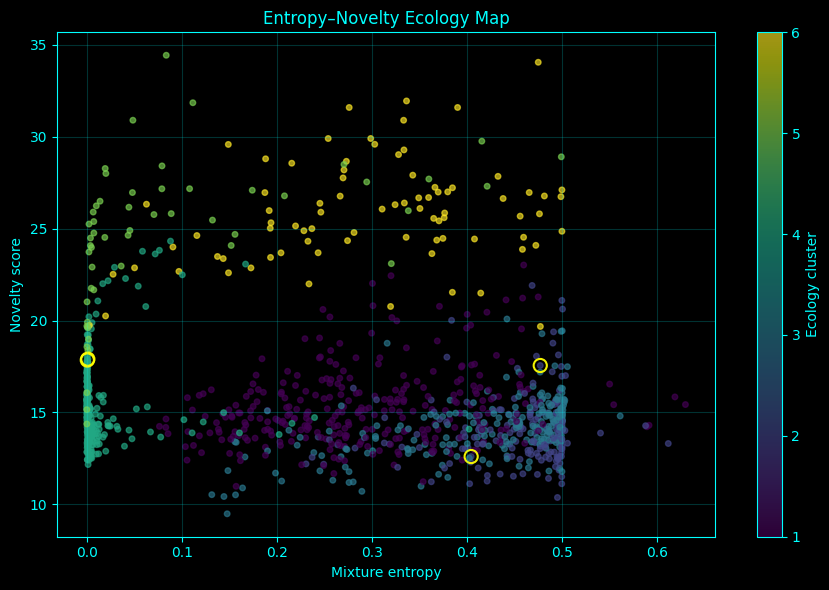

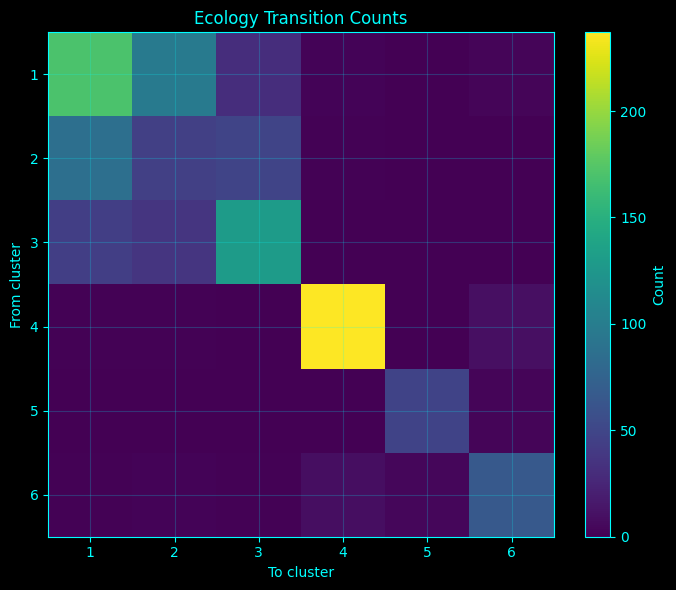

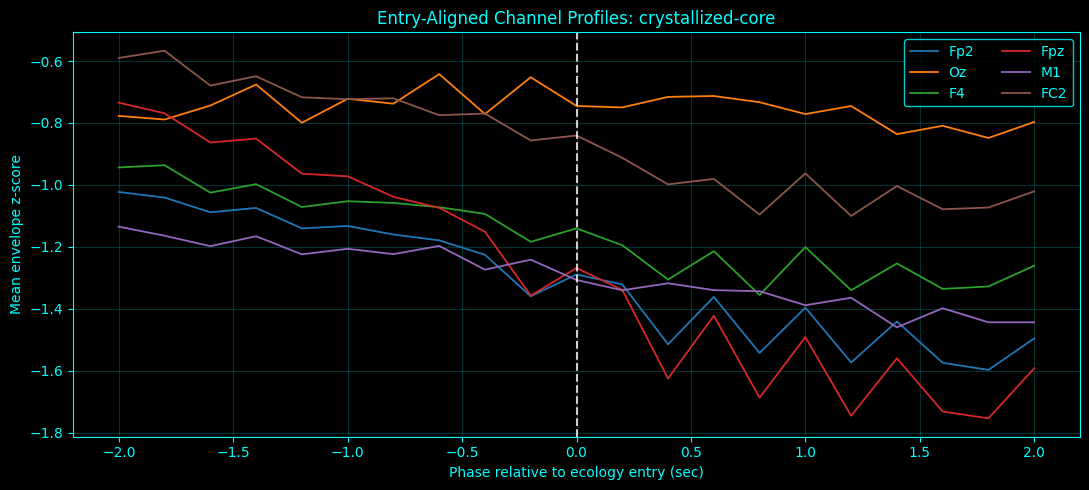

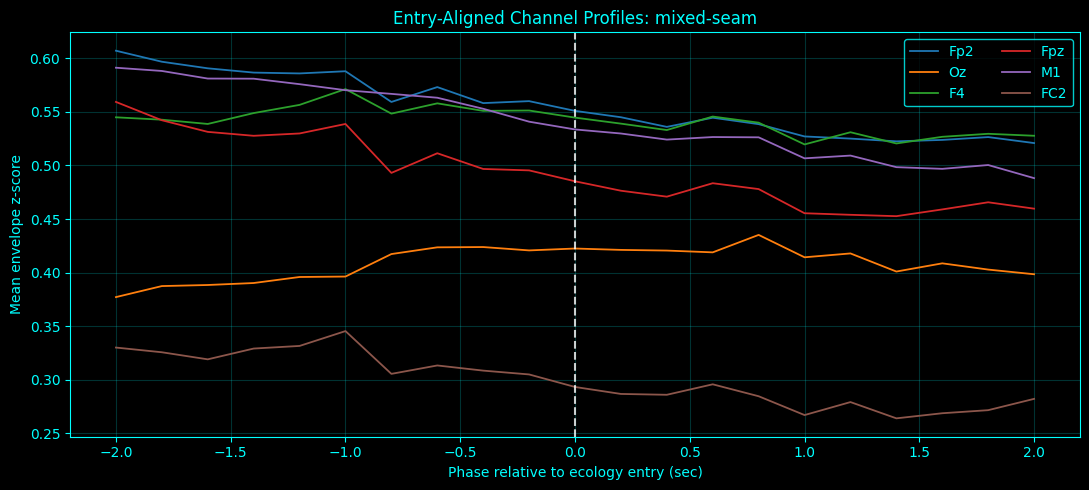

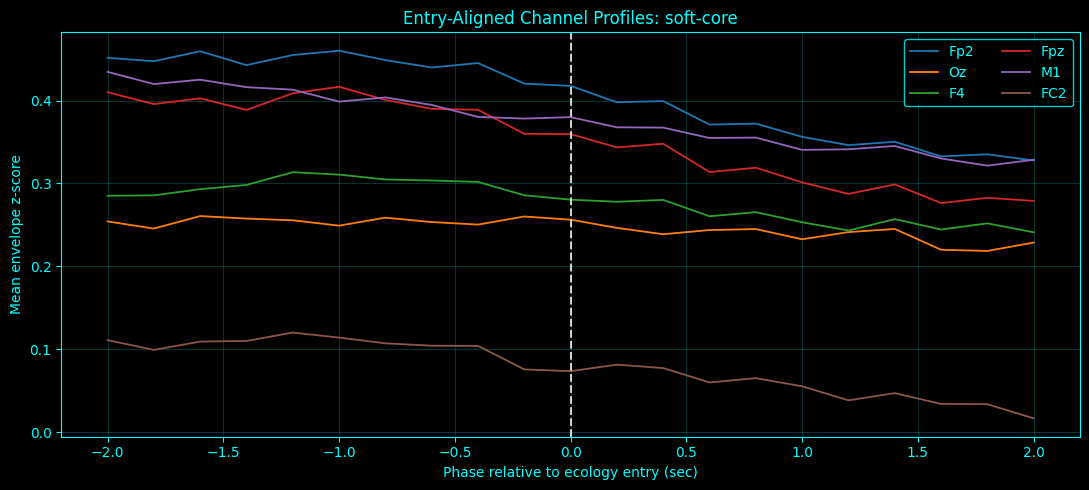

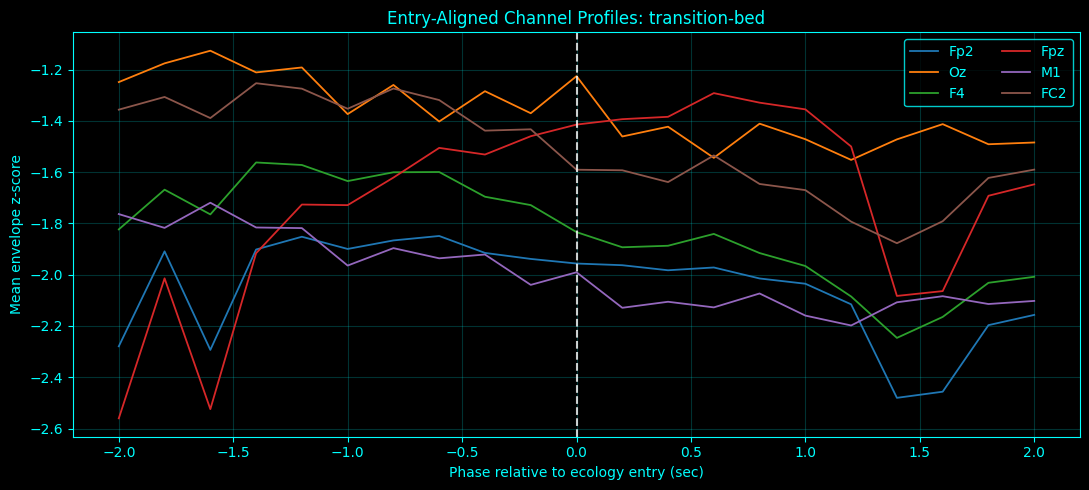


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/motif_field_with_ecology_labels.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/ecology_cluster_summary.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/ecology_segments.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/near_flat_ecology_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/ecology_entry_channel_profiles.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/ecology_transition_counts.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/motif_field_ecology_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/plots

Ecology cluster summary:
 ecology_cluster  count  dominant_motif_mode  novelty_score_

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

field_dir = os.path.join(base_dir, "results", "continuous_motif_field_v1")
geom_dir = os.path.join(base_dir, "results", "local_banach_curvature_bootstrap_v1")
temporal_dir = os.path.join(base_dir, "results", "stable_curvature_temporal_episodes_v1")

field_csv = os.path.join(field_dir, "continuous_motif_field.csv")
near_flat_field_csv = os.path.join(field_dir, "near_flat_soft_motif_context.csv")
all_local_csv = os.path.join(geom_dir, "local_chart_curvature_all_states.csv")
channel_contrast_csv = os.path.join(temporal_dir, "stable_vs_nonstable_channel_envelope_contrast.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "motif_field_ecology_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# ecology discovery controls
n_ecology_states = 6
entry_window_sec = 2.0
entry_bin_sec = 0.20
top_k_channels = 6
env_smooth_sec = 0.150

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    w = max(int(w), 1)
    if w <= 1:
        return x.copy()
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(x, kernel, mode="same")

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

def zscore_cols(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    return (X - mu) / (sd + eps), mu, sd

def interp_profile(bin_centers, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if len(x) == 0:
        return np.full(len(bin_centers), np.nan)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if len(np.unique(x)) == 1:
        return np.full(len(bin_centers), y[0])

    return np.interp(bin_centers, x, y, left=y[0], right=y[-1])

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def contiguous_segments(times, labels, gap_sec=0.5):
    times = np.asarray(times, dtype=float)
    labels = np.asarray(labels)
    if len(times) == 0:
        return []

    segments = []
    start_i = 0

    for i in range(1, len(times)):
        broken = (labels[i] != labels[i - 1]) or ((times[i] - times[i - 1]) > gap_sec)
        if broken:
            segments.append((start_i, i - 1))
            start_i = i

    segments.append((start_i, len(times) - 1))
    return segments

# -------------------------------------------------------
# heuristic naming layer on top of unsupervised clusters
# -------------------------------------------------------
def ecology_name(row, novelty_q75, novelty_q90, entropy_q75, margin_q25, margin_q75):
    novelty = row["novelty_score_mean"]
    entropy = row["mixture_entropy_mean"]
    margin = row["dominance_margin_mean"]

    if novelty >= novelty_q90 and entropy < entropy_q75 and margin >= margin_q75:
        return "novel-island"
    if entropy >= entropy_q75 and margin <= margin_q25:
        return "mixed-seam"
    if novelty >= novelty_q75 and entropy >= entropy_q75:
        return "rupture-front"
    if entropy < entropy_q75 and margin >= margin_q75 and novelty < novelty_q75:
        return "crystallized-core"
    if entropy < entropy_q75 and margin < margin_q75:
        return "soft-core"
    return "transition-bed"

novelty_q75 = np.quantile(cluster_summary_df["novelty_score_mean"], 0.75)
novelty_q90 = np.quantile(cluster_summary_df["novelty_score_mean"], 0.90)
entropy_q75 = np.quantile(cluster_summary_df["mixture_entropy_mean"], 0.75)
margin_q25 = np.quantile(cluster_summary_df["dominance_margin_mean"], 0.25)
margin_q75 = np.quantile(cluster_summary_df["dominance_margin_mean"], 0.75)

cluster_summary_df["ecology_name"] = cluster_summary_df.apply(
    lambda r: ecology_name(r, novelty_q75, novelty_q90, entropy_q75, margin_q25, margin_q75),
    axis=1
)

cluster_to_name = dict(zip(cluster_summary_df["ecology_cluster"], cluster_summary_df["ecology_name"]))
field_df["ecology_name"] = field_df["ecology_cluster"].map(cluster_to_name)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
field_df = pd.read_csv(field_csv).sort_values("center_time_sec").reset_index(drop=True)
all_local_df = pd.read_csv(all_local_csv).sort_values("time_sec").reset_index(drop=True)

if os.path.exists(near_flat_field_csv):
    near_flat_field_df = pd.read_csv(near_flat_field_csv)
else:
    near_flat_field_df = pd.DataFrame()

if os.path.exists(channel_contrast_csv):
    channel_contrast_df = pd.read_csv(channel_contrast_csv).sort_values(
        "cohen_d_stable_vs_nonstable", ascending=False
    ).reset_index(drop=True)
    top_channels = channel_contrast_df["channel"].head(top_k_channels).tolist()
else:
    top_channels = ["Fp2", "Oz", "F4", "Fpz", "M1", "FC2"]

top_channel_idx = [eeg_channel_names.index(ch) for ch in top_channels]

# geometry fields
all_local_df["abs_laplacian_norm_proxy"] = np.abs(all_local_df["laplacian_norm_proxy"].values)

# nearest-time merge from local geometry into field windows
geom_merge_cols = [
    "time_sec",
    "frobenius_norm_proxy",
    "abs_laplacian_norm_proxy",
    "transition_distortion_B",
    "reduced_logvol_per_rank_B",
    "mean_banach_neighbor_radius",
    "fit_r2",
]
geom_df = all_local_df[geom_merge_cols].copy().sort_values("time_sec").reset_index(drop=True)

field_df = pd.merge_asof(
    field_df.sort_values("center_time_sec"),
    geom_df,
    left_on="center_time_sec",
    right_on="time_sec",
    direction="nearest"
).drop(columns=["time_sec"])

# -------------------------------------------------------
# ECOLOGY FEATURE MATRIX
# -------------------------------------------------------
motif_activation_cols = [c for c in field_df.columns if c.endswith("_activation")]
feature_cols = [
    "novelty_score",
    "mixture_entropy",
    "dominance_margin",
    "frobenius_norm_proxy",
    "abs_laplacian_norm_proxy",
    "transition_distortion_B",
    "reduced_logvol_per_rank_B",
    "mean_banach_neighbor_radius",
    "fit_r2",
] + motif_activation_cols

X = field_df[feature_cols].values
Xz, mu, sd = zscore_cols(X)

# unsupervised ecology discovery
Z = linkage(Xz, method="ward")
cluster_ids = fcluster(Z, t=n_ecology_states, criterion="maxclust")
field_df["ecology_cluster"] = cluster_ids

# summarize clusters
cluster_rows = []
for cid in sorted(field_df["ecology_cluster"].unique()):
    sub = field_df[field_df["ecology_cluster"] == cid]
    dominant_motif_mode = int(sub["dominant_motif"].mode().iloc[0])

    cluster_rows.append({
        "ecology_cluster": int(cid),
        "count": int(len(sub)),
        "dominant_motif_mode": dominant_motif_mode,
        "novelty_score_mean": safe_mean(sub["novelty_score"].values),
        "mixture_entropy_mean": safe_mean(sub["mixture_entropy"].values),
        "dominance_margin_mean": safe_mean(sub["dominance_margin"].values),
        "frobenius_norm_proxy_mean": safe_mean(sub["frobenius_norm_proxy"].values),
        "abs_laplacian_norm_proxy_mean": safe_mean(sub["abs_laplacian_norm_proxy"].values),
        "transition_distortion_B_mean": safe_mean(sub["transition_distortion_B"].values),
        "reduced_logvol_per_rank_B_mean": safe_mean(sub["reduced_logvol_per_rank_B"].values),
        "mean_banach_neighbor_radius_mean": safe_mean(sub["mean_banach_neighbor_radius"].values),
        "fit_r2_mean": safe_mean(sub["fit_r2"].values),
    })

cluster_summary_df = pd.DataFrame(cluster_rows).sort_values("ecology_cluster").reset_index(drop=True)

# heuristic naming layer on top of unsupervised clusters
novelty_q75 = np.quantile(cluster_summary_df["novelty_score_mean"], 0.75)
novelty_q90 = np.quantile(cluster_summary_df["novelty_score_mean"], 0.90)
entropy_q75 = np.quantile(cluster_summary_df["mixture_entropy_mean"], 0.75)
margin_q25 = np.quantile(cluster_summary_df["dominance_margin_mean"], 0.25)
margin_q75 = np.quantile(cluster_summary_df["dominance_margin_mean"], 0.75)

cluster_summary_df["ecology_name"] = cluster_summary_df.apply(
    lambda r: ecology_name(r, novelty_q75, novelty_q90, entropy_q75, margin_q25, margin_q75),
    axis=1
)

cluster_to_name = dict(zip(cluster_summary_df["ecology_cluster"], cluster_summary_df["ecology_name"]))
field_df["ecology_name"] = field_df["ecology_cluster"].map(cluster_to_name)

# -------------------------------------------------------
# CONTIGUOUS ECOLOGY SEGMENTS
# -------------------------------------------------------
segments = contiguous_segments(
    field_df["center_time_sec"].values,
    field_df["ecology_cluster"].values,
    gap_sec=0.5
)

segment_rows = []
for seg_id, (i0, i1) in enumerate(segments, start=1):
    sub = field_df.iloc[i0:i1 + 1]
    segment_rows.append({
        "segment_id": seg_id,
        "start_time_sec": float(sub["center_time_sec"].iloc[0]),
        "end_time_sec": float(sub["center_time_sec"].iloc[-1]),
        "duration_sec": float(sub["center_time_sec"].iloc[-1] - sub["center_time_sec"].iloc[0]),
        "n_windows": int(len(sub)),
        "ecology_cluster": int(sub["ecology_cluster"].mode().iloc[0]),
        "ecology_name": sub["ecology_name"].mode().iloc[0],
        "dominant_motif_mode": int(sub["dominant_motif"].mode().iloc[0]),
        "novelty_mean": safe_mean(sub["novelty_score"].values),
        "entropy_mean": safe_mean(sub["mixture_entropy"].values),
        "margin_mean": safe_mean(sub["dominance_margin"].values),
    })

segment_df = pd.DataFrame(segment_rows).sort_values("start_time_sec").reset_index(drop=True)

# -------------------------------------------------------
# NEAR-FLAT ECOLOGY CONTEXT
# -------------------------------------------------------
near_flat_ecology_rows = []

if len(near_flat_field_df) > 0:
    for _, row in near_flat_field_df.iterrows():
        t = float(row["time_sec"])
        idx = int(np.argmin(np.abs(field_df["center_time_sec"].values - t)))
        fr = field_df.iloc[idx]

        near_flat_ecology_rows.append({
            "time_sec": t,
            "nearest_field_time_sec": float(fr["center_time_sec"]),
            "ecology_cluster": int(fr["ecology_cluster"]),
            "ecology_name": fr["ecology_name"],
            "dominant_motif": int(fr["dominant_motif"]),
            "novelty_score": float(fr["novelty_score"]),
            "mixture_entropy": float(fr["mixture_entropy"]),
            "dominance_margin": float(fr["dominance_margin"]),
            "motif_1_activation": float(fr.get("motif_1_activation", np.nan)),
            "motif_2_activation": float(fr.get("motif_2_activation", np.nan)),
            "motif_3_activation": float(fr.get("motif_3_activation", np.nan)),
            "motif_4_activation": float(fr.get("motif_4_activation", np.nan)),
        })

near_flat_ecology_df = pd.DataFrame(near_flat_ecology_rows)

# -------------------------------------------------------
# EEG ENTRY PROFILES BY ECOLOGY TYPE
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]
analytic = hilbert(EEG_segment, axis=0)
envelope = np.abs(analytic)
env_z = (envelope - np.mean(envelope, axis=0, keepdims=True)) / (np.std(envelope, axis=0, keepdims=True) + eps)

smooth_w = int(env_smooth_sec * sampling_rate)
env_z_smooth = np.column_stack([
    moving_average(env_z[:, ch], smooth_w) for ch in range(env_z.shape[1])
])

sample_time = start_time + np.arange(len(EEG_segment)) * dt
entry_bins = np.arange(-entry_window_sec, entry_window_sec + entry_bin_sec, entry_bin_sec)

entry_rows = []

for eco_name in sorted(field_df["ecology_name"].unique()):
    eco_seg = segment_df[segment_df["ecology_name"] == eco_name]
    if len(eco_seg) == 0:
        continue

    for ch_idx, ch_name in zip(top_channel_idx, top_channels):
        aligned_profiles = []

        for _, seg in eco_seg.iterrows():
            t0 = float(seg["start_time_sec"])
            mask = (sample_time >= t0 - entry_window_sec) & (sample_time <= t0 + entry_window_sec)
            if not np.any(mask):
                continue

            phase = sample_time[mask] - t0
            prof = interp_profile(entry_bins, phase, env_z_smooth[mask, ch_idx])
            aligned_profiles.append(prof)

        if len(aligned_profiles) == 0:
            continue

        aligned_profiles = np.vstack(aligned_profiles)
        mean_prof = np.nanmean(aligned_profiles, axis=0)

        for p, v in zip(entry_bins, mean_prof):
            entry_rows.append({
                "ecology_name": eco_name,
                "channel": ch_name,
                "phase_sec": float(p),
                "mean_env_z": float(v),
            })

entry_profile_df = pd.DataFrame(entry_rows)

# -------------------------------------------------------
# ECOLOGY MANIFOLD EMBEDDING
# -------------------------------------------------------
Y, eigs, _ = pca_2d(Xz)
field_df["eco_x"] = Y[:, 0]
field_df["eco_y"] = Y[:, 1]

cluster_centers = []
for cid in sorted(field_df["ecology_cluster"].unique()):
    sub = field_df[field_df["ecology_cluster"] == cid]
    cluster_centers.append({
        "ecology_cluster": int(cid),
        "ecology_name": sub["ecology_name"].iloc[0],
        "eco_x": float(np.mean(sub["eco_x"])),
        "eco_y": float(np.mean(sub["eco_y"])),
    })
cluster_center_df = pd.DataFrame(cluster_centers)

# -------------------------------------------------------
# TRANSITION COUNTS BETWEEN ECOLOGY STATES
# -------------------------------------------------------
transition_rows = []
for i in range(len(field_df) - 1):
    a = field_df["ecology_cluster"].iloc[i]
    b = field_df["ecology_cluster"].iloc[i + 1]
    transition_rows.append({"from_cluster": int(a), "to_cluster": int(b)})

transition_df = pd.DataFrame(transition_rows)
if len(transition_df) > 0:
    transition_count_df = transition_df.value_counts().reset_index(name="count")
else:
    transition_count_df = pd.DataFrame(columns=["from_cluster", "to_cluster", "count"])

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
field_out_csv = os.path.join(out_dir, "motif_field_with_ecology_labels.csv")
cluster_csv = os.path.join(out_dir, "ecology_cluster_summary.csv")
segment_csv = os.path.join(out_dir, "ecology_segments.csv")
near_flat_csv = os.path.join(out_dir, "near_flat_ecology_context.csv")
entry_csv = os.path.join(out_dir, "ecology_entry_channel_profiles.csv")
transition_csv = os.path.join(out_dir, "ecology_transition_counts.csv")
summary_txt = os.path.join(out_dir, "motif_field_ecology_summary.txt")

field_df.to_csv(field_out_csv, index=False)
cluster_summary_df.to_csv(cluster_csv, index=False)
segment_df.to_csv(segment_csv, index=False)
near_flat_ecology_df.to_csv(near_flat_csv, index=False)
entry_profile_df.to_csv(entry_csv, index=False)
transition_count_df.to_csv(transition_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Motif Field Ecology Atlas Summary\n")
    f.write("================================\n\n")
    f.write(f"n_ecology_states = {n_ecology_states}\n")
    f.write(f"Top channels = {top_channels}\n\n")

    f.write("Ecology cluster summary:\n")
    f.write(cluster_summary_df.to_string(index=False))
    f.write("\n\n")

    f.write("Top 20 longest ecology segments:\n")
    f.write(segment_df.sort_values('duration_sec', ascending=False).head(20).to_string(index=False))
    f.write("\n\n")

    if len(near_flat_ecology_df) > 0:
        f.write("Near-flat ecology context:\n")
        f.write(near_flat_ecology_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Ecology timeline
fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["center_time_sec"].values,
    field_df["ecology_cluster"].values,
    c=field_df["novelty_score"].values,
    s=16,
    alpha=0.85
)
ax.set_title("Motif Field Ecology Timeline")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Ecology cluster")

if len(near_flat_ecology_df) > 0:
    ax.scatter(
        near_flat_ecology_df["time_sec"].values,
        near_flat_ecology_df["ecology_cluster"].values,
        s=70,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot1_path = os.path.join(plots_dir, "ecology_timeline.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Ecology manifold
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["eco_x"].values,
    field_df["eco_y"].values,
    c=field_df["ecology_cluster"].values,
    s=12,
    alpha=0.22
)

for _, row in cluster_center_df.iterrows():
    ax.scatter(row["eco_x"], row["eco_y"], s=160, color="white", alpha=0.9)
    ax.text(row["eco_x"], row["eco_y"], row["ecology_name"], fontsize=9)

if len(near_flat_ecology_df) > 0:
    nf_merge = pd.merge_asof(
        near_flat_ecology_df.sort_values("nearest_field_time_sec"),
        field_df[["center_time_sec", "eco_x", "eco_y"]].sort_values("center_time_sec"),
        left_on="nearest_field_time_sec",
        right_on="center_time_sec",
        direction="nearest"
    )
    ax.scatter(
        nf_merge["eco_x"].values,
        nf_merge["eco_y"].values,
        s=110,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.6,
        alpha=0.95
    )

ax.set_title("Motif Field Ecology Manifold")
ax.set_xlabel("Ecology axis 1")
ax.set_ylabel("Ecology axis 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Ecology cluster")

plot2_path = os.path.join(plots_dir, "ecology_manifold.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Entropy vs novelty colored by ecology
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["mixture_entropy"].values,
    field_df["novelty_score"].values,
    c=field_df["ecology_cluster"].values,
    s=16,
    alpha=0.65
)

if len(near_flat_ecology_df) > 0:
    ax.scatter(
        near_flat_ecology_df["mixture_entropy"].values,
        near_flat_ecology_df["novelty_score"].values,
        s=90,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Entropy–Novelty Ecology Map")
ax.set_xlabel("Mixture entropy")
ax.set_ylabel("Novelty score")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Ecology cluster")

plot3_path = os.path.join(plots_dir, "entropy_novelty_ecology_map.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Ecology transition heatmap
clusters = sorted(field_df["ecology_cluster"].unique())
cluster_to_idx = {c: i for i, c in enumerate(clusters)}
T = np.zeros((len(clusters), len(clusters)), dtype=float)
for _, row in transition_count_df.iterrows():
    T[cluster_to_idx[int(row["from_cluster"])], cluster_to_idx[int(row["to_cluster"])]] = row["count"]

fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(T, aspect="auto")
ax.set_xticks(np.arange(len(clusters)))
ax.set_yticks(np.arange(len(clusters)))
ax.set_xticklabels(clusters)
ax.set_yticklabels(clusters)
ax.set_title("Ecology Transition Counts")
ax.set_xlabel("To cluster")
ax.set_ylabel("From cluster")

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Count")

plot4_path = os.path.join(plots_dir, "ecology_transition_counts.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Entry channel profiles by ecology
for eco_name in sorted(entry_profile_df["ecology_name"].unique()):
    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    style_ax(ax)

    sub_all = entry_profile_df[entry_profile_df["ecology_name"] == eco_name]
    for ch_name in top_channels:
        sub = sub_all[sub_all["channel"] == ch_name]
        if len(sub) == 0:
            continue
        ax.plot(
            sub["phase_sec"].values,
            sub["mean_env_z"].values,
            linewidth=1.3,
            label=ch_name
        )

    ax.axvline(0.0, color="white", linestyle="--", alpha=0.8)
    ax.set_title(f"Entry-Aligned Channel Profiles: {eco_name}")
    ax.set_xlabel("Phase relative to ecology entry (sec)")
    ax.set_ylabel("Mean envelope z-score")
    ax.legend(ncol=2)

    plot_path = os.path.join(plots_dir, f"entry_profiles_{eco_name}.png")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

print("\nSaved:")
print(field_out_csv)
print(cluster_csv)
print(segment_csv)
print(near_flat_csv)
print(entry_csv)
print(transition_csv)
print(summary_txt)
print(plots_dir)

print("\nEcology cluster summary:")
print(cluster_summary_df.to_string(index=False))

print("\nTop 15 longest ecology segments:")
print(segment_df.sort_values("duration_sec", ascending=False).head(15).to_string(index=False))

if len(near_flat_ecology_df) > 0:
    print("\nNear-flat ecology context:")
    print(near_flat_ecology_df.to_string(index=False))